# Baseline

In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

In [4]:
epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2006-06-01',max_date='2020-06-01')

/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:171: UserWarning: 1 rows with missing tokenized IDs will be dropped from 'shapedata'. Dropped original IDs: ['11000']
  warnings.warn(


In [6]:
len(epidata.data)

2

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:361: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:374: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


(<Figure size 1100x900 with 4 Axes>,
 <Axes: title={'center': 'cases in node: 69'}>)

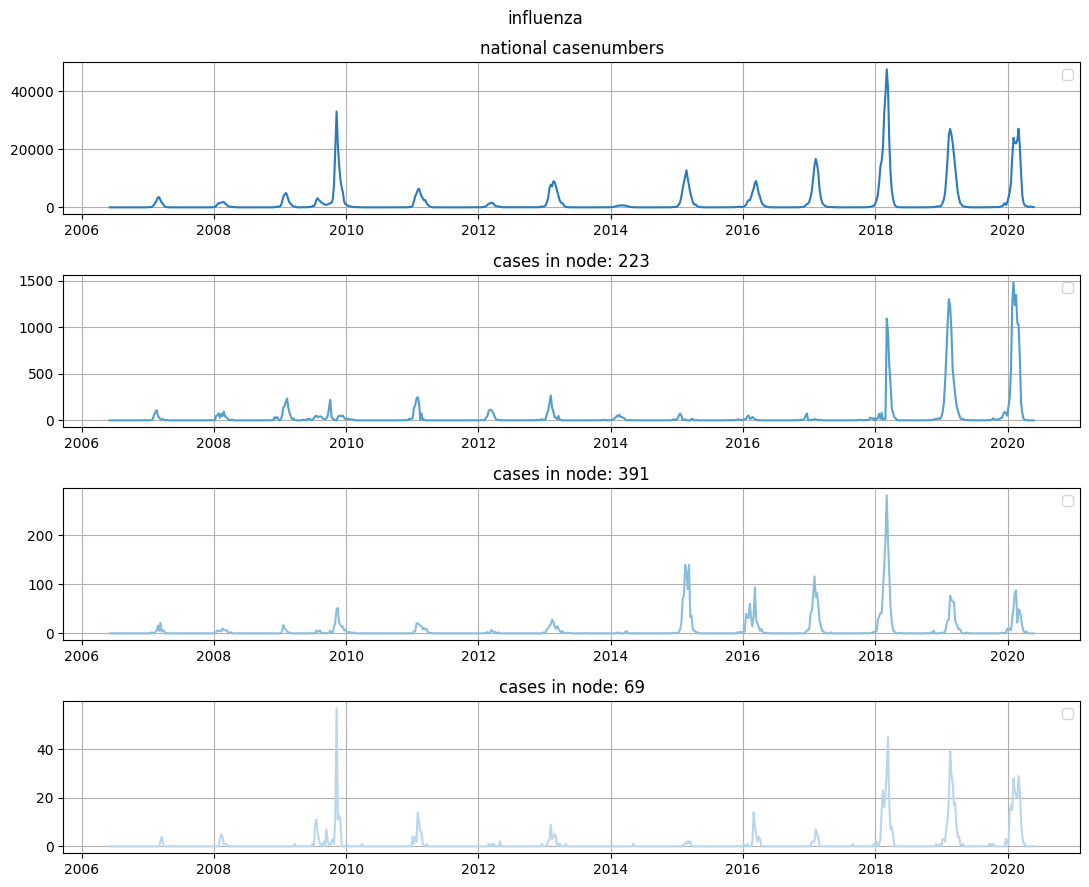

In [2]:
token_munich     = 223
token_jena       = 391
token_oberhausen = 69
token_hannover   = 26

epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2006-06-01',max_date='2020-06-01')
epidata.log_transform_target()
epidata.add_time_features()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(range(1,3))
epidata.preview([token_munich,token_jena,token_oberhausen],status = 'raw', y ='cases')

## 1. Local Trend Predictor

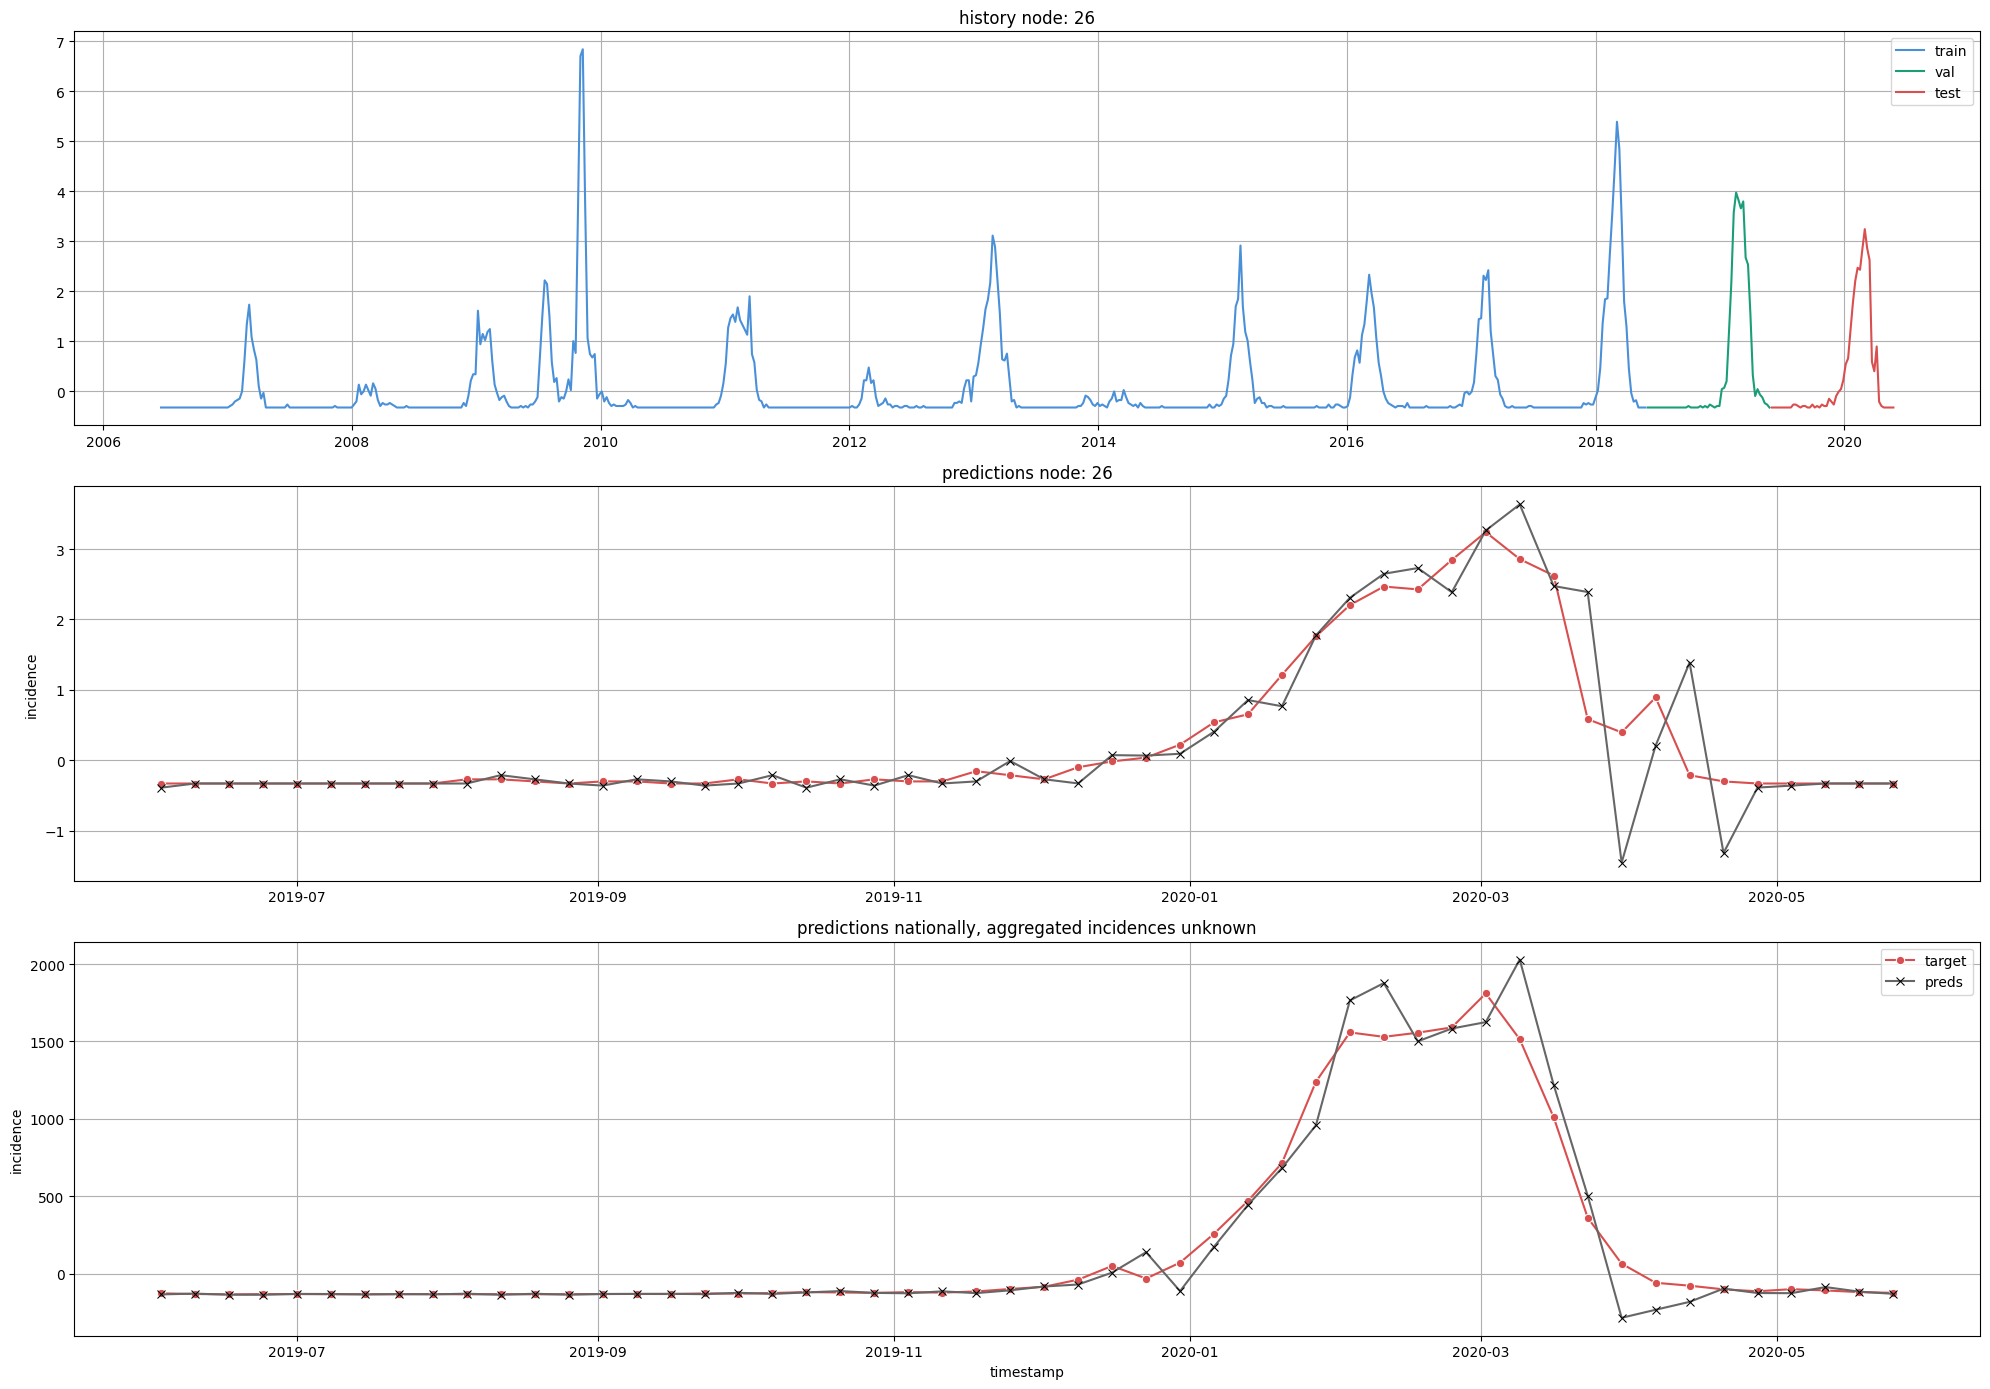

In [3]:
from src.models.localtrendpredictor import LocalTrendPredictor

dataloader_copy = epidata

ltp = LocalTrendPredictor(dataloader_copy)
ltp.forecast()
ltp.show_forecasts(26)

## 2. XGB

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[0]	train-rmse:0.96176	val-rmse:1.57008
[20]	train-rmse:0.53951	val-rmse:0.81968
[40]	train-rmse:0.43049	val-rmse:0.59276
[60]	train-rmse:0.40756	val-rmse:0.53847
[80]	train-rmse:0.40074	val-rmse:0.52444
[100]	train-rmse:0.39708	val-rmse:0.52086
[120]	train-rmse:0.39436	val-rmse:0.52027
[140]	train-rmse:0.39197	val-rmse:0.52005
[155]	train-rmse:0.39044	val-rmse:0.52029


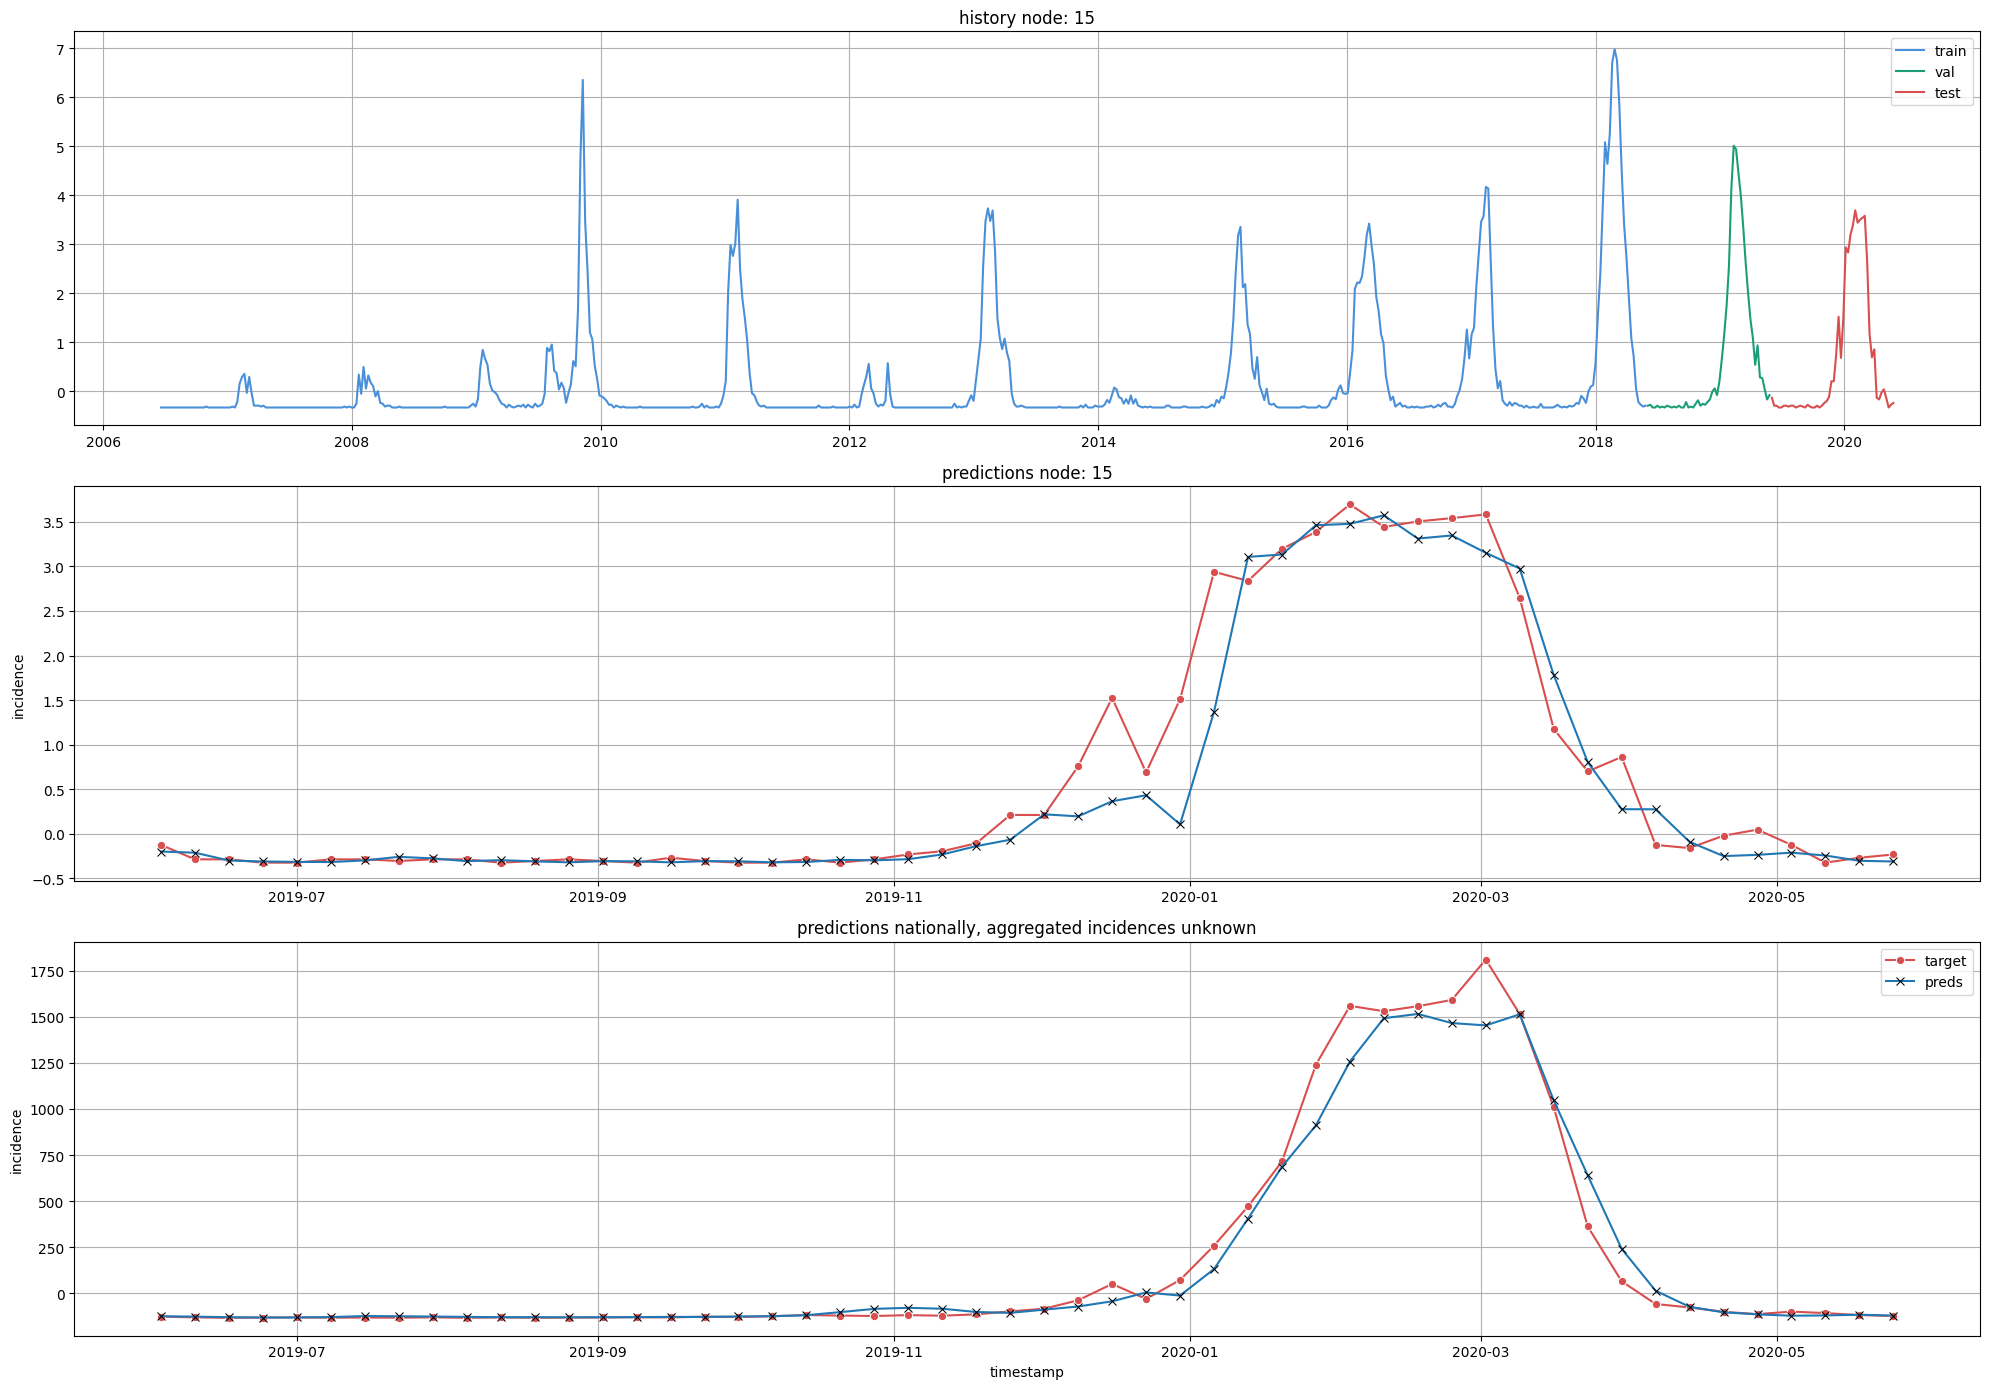

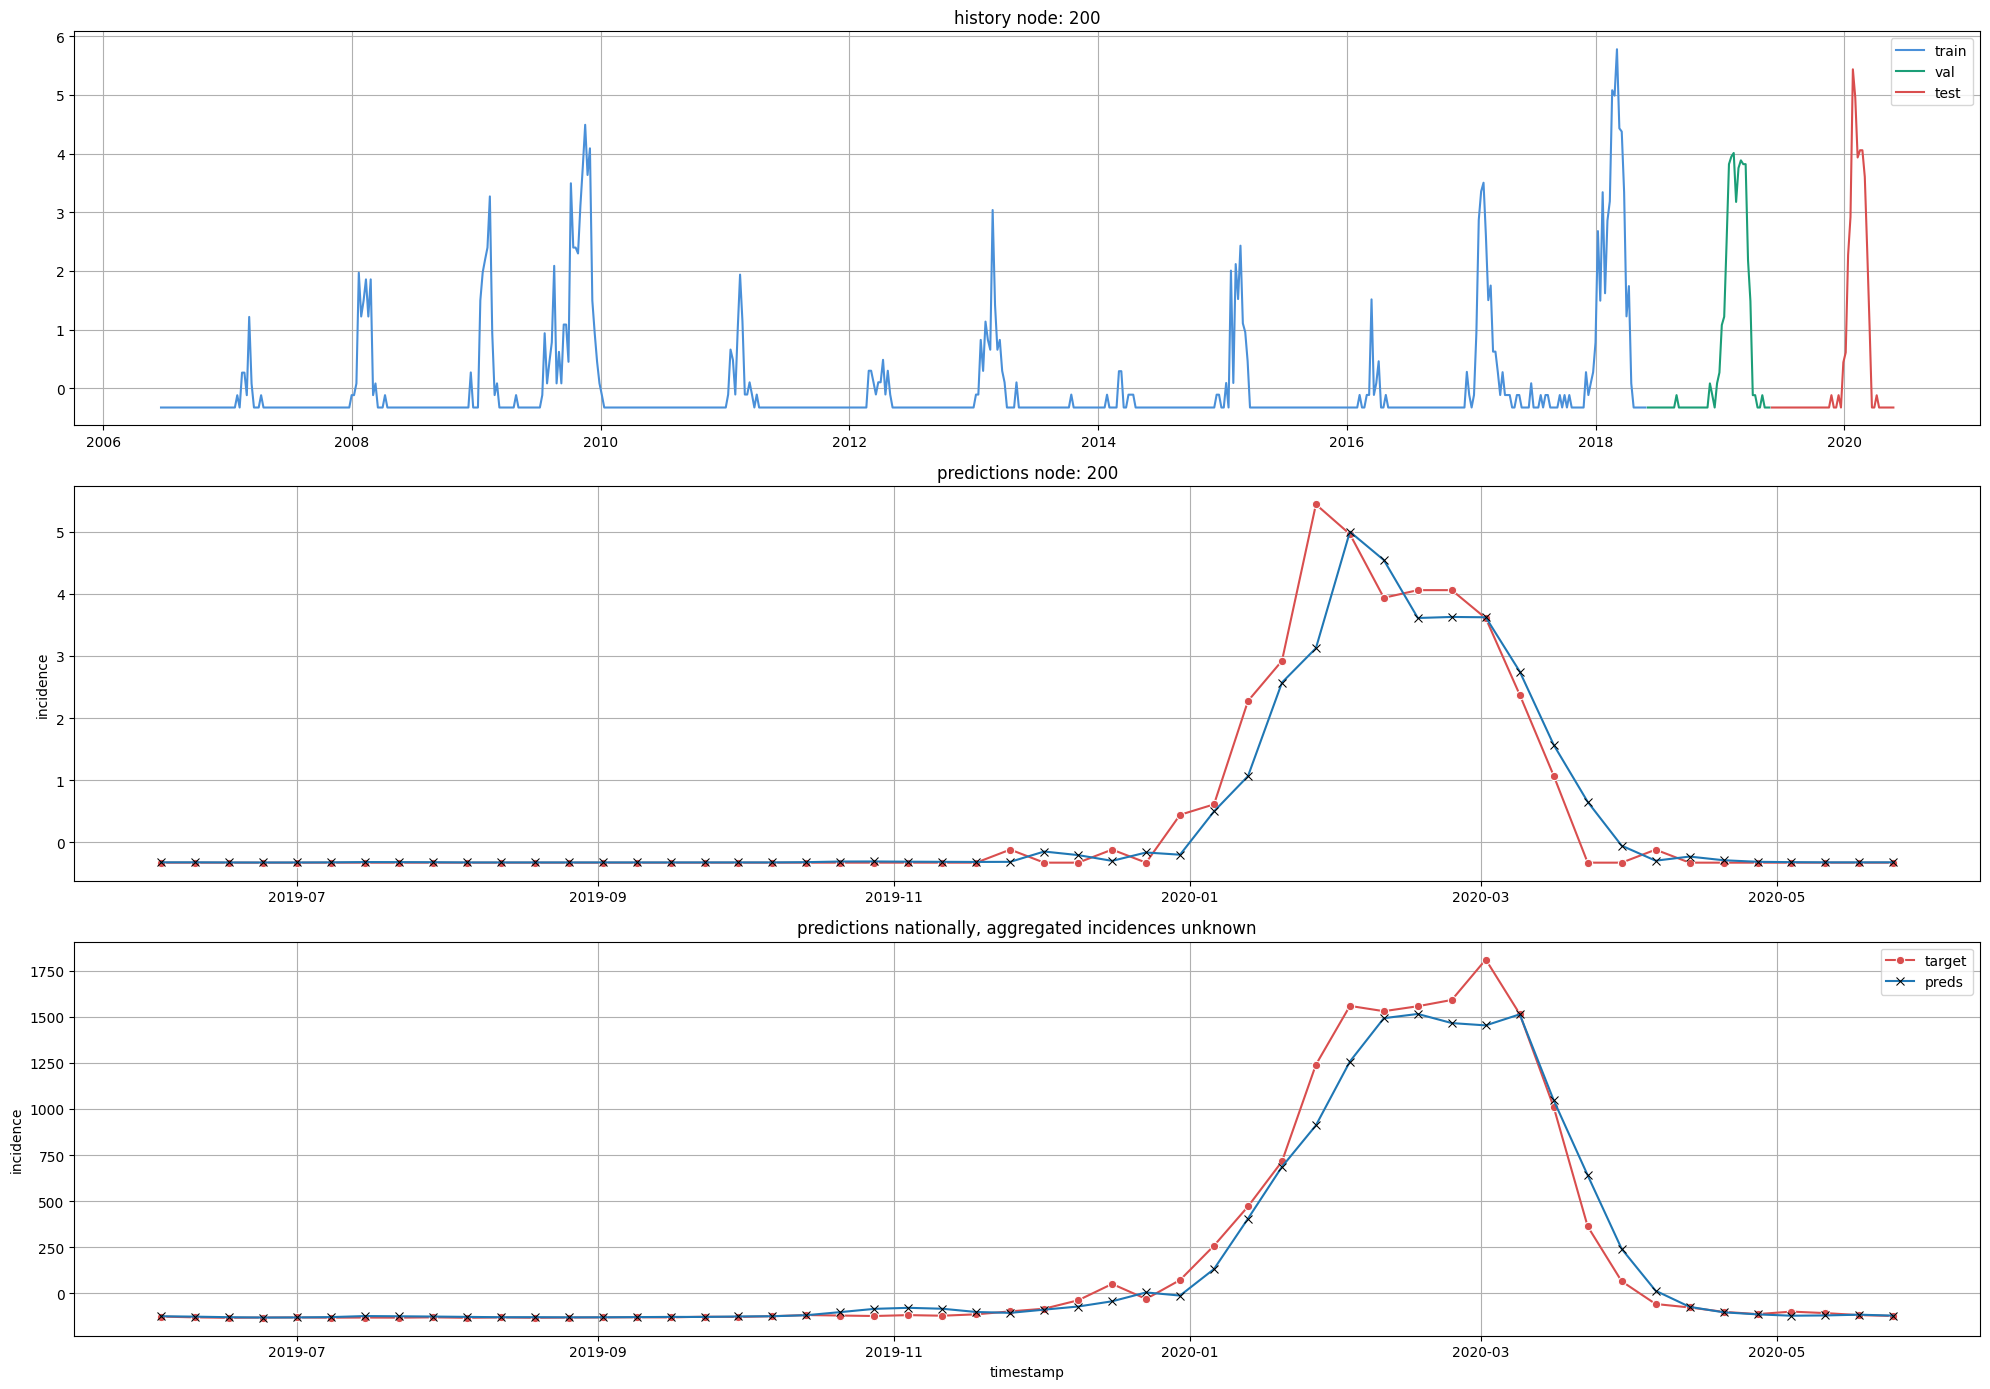

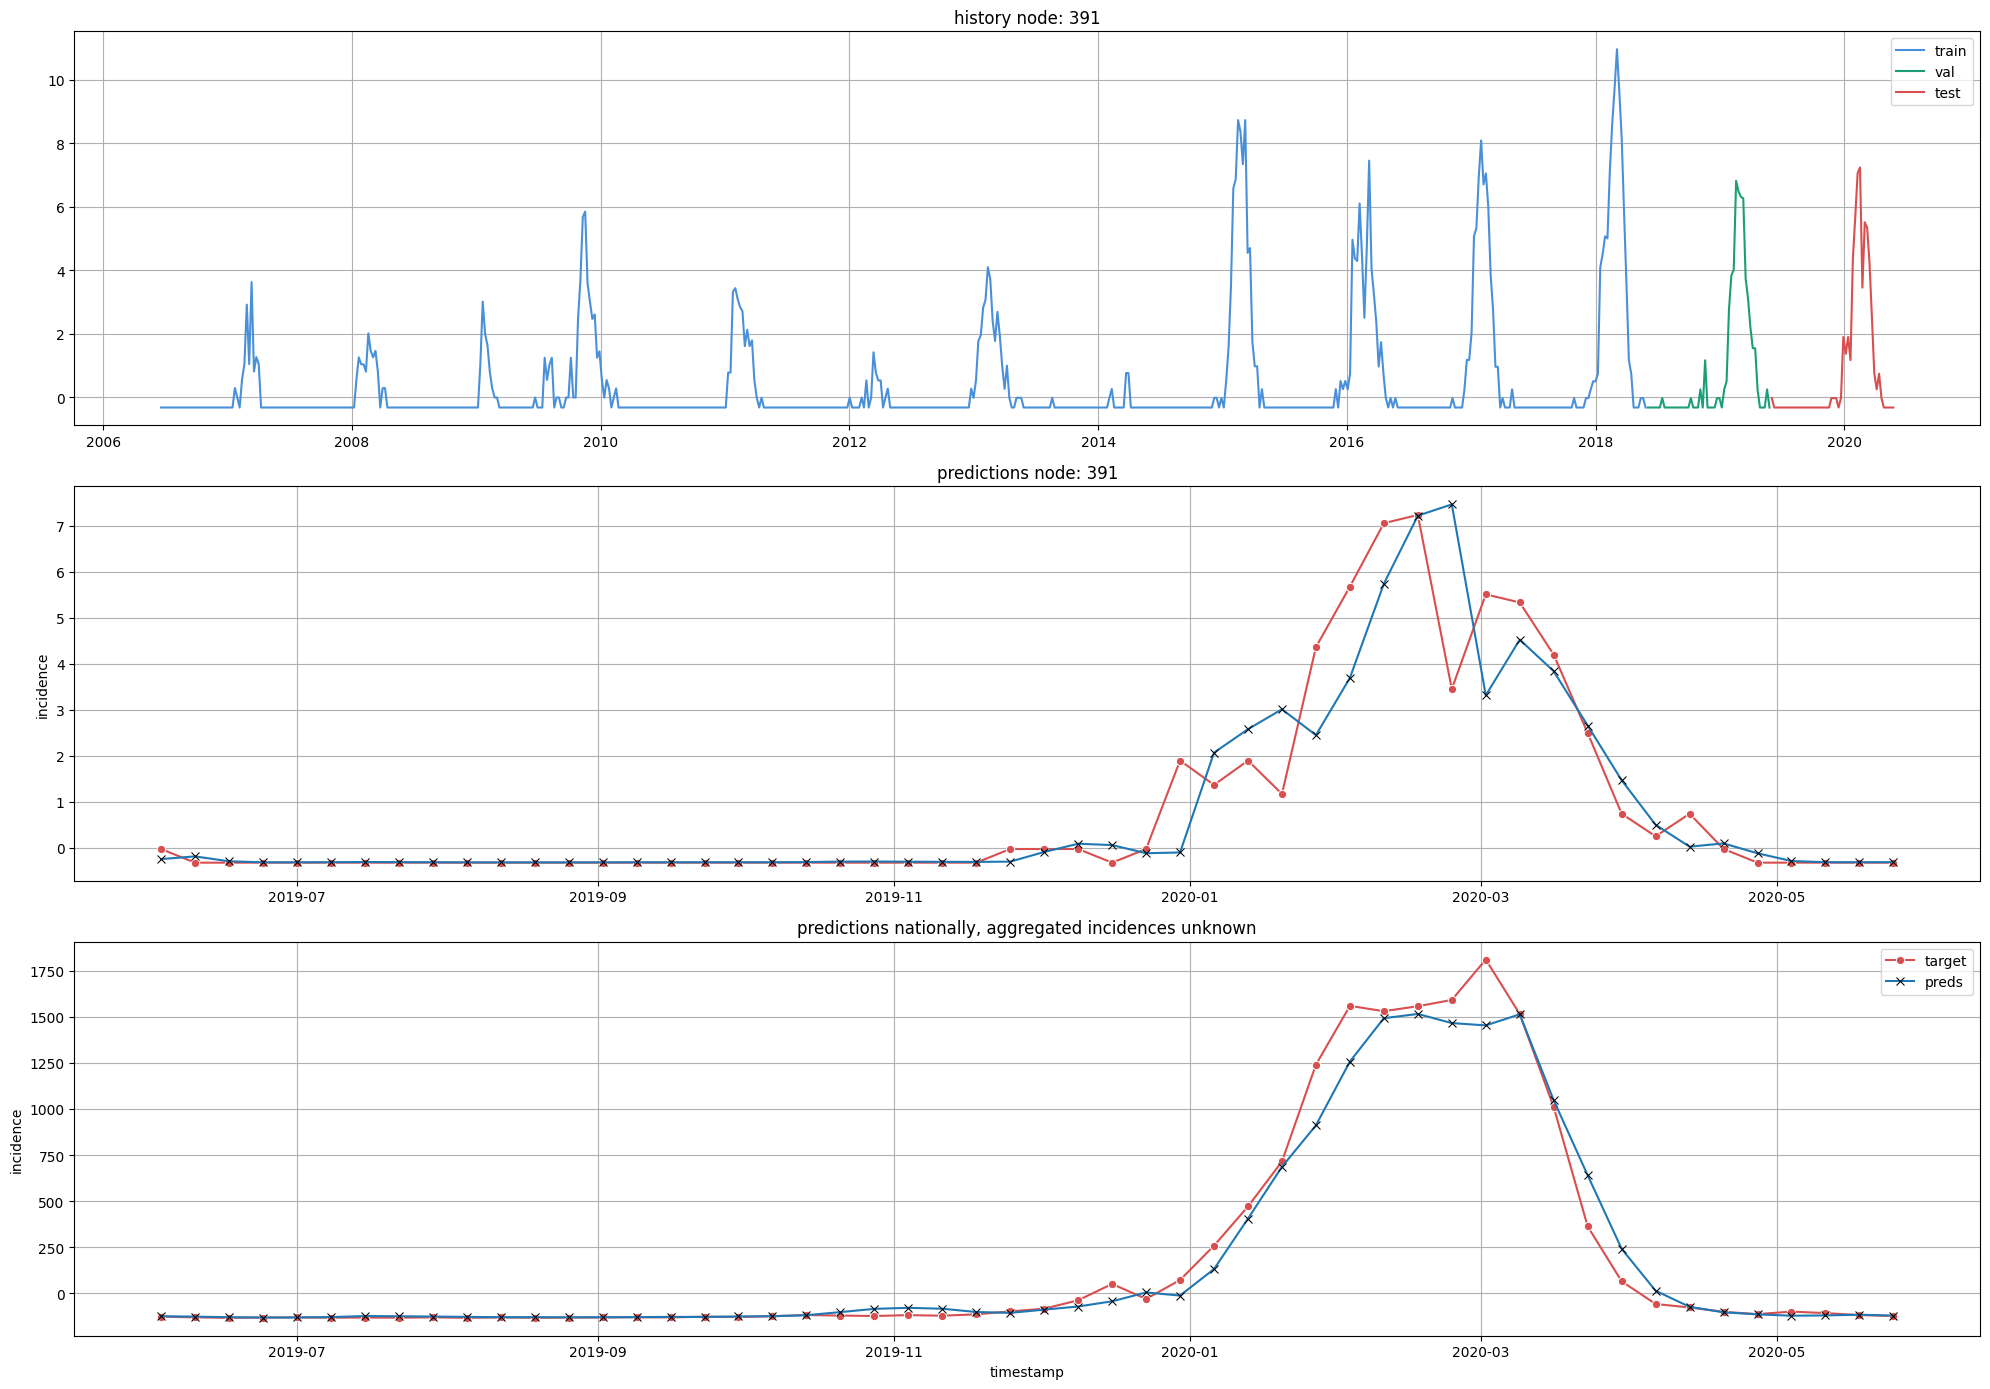

In [4]:
from src.models import XGBoostAutoRegressor

xgb_model = XGBoostAutoRegressor(epidata)
xgb_model.forecast()
xgb_model.show_forecasts(15)
xgb_model.show_forecasts(200)
xgb_model.show_forecasts(391)

In [5]:
xgb_model.dataloader.norm_params

{'method': 'zscore',
 'params': {'population_size': {'mean': np.float64(198710.04730533337),
   'std': np.float64(165132.57017070544)},
  'timestamp_sin': {'mean': np.float64(0.000385101214873255),
   'std': np.float64(0.706010455850892)},
  'timestamp_cos': {'mean': np.float64(0.003171593846958582),
   'std': np.float64(0.7081969469148056)},
  'incidence': {'mean': np.float64(0.09472202852182825),
   'std': np.float64(0.2896307192547196)},
  'preds': {'mean': np.float64(0.09472202852182825),
   'std': np.float64(0.2896307192547196)},
  'incidence_lag1': {'mean': np.float64(0.09472202852182825),
   'std': np.float64(0.2896307192547196)},
  'incidence_lag2': {'mean': np.float64(0.09472202852182825),
   'std': np.float64(0.2896307192547196)}}}

In [6]:
ml = xgb_model

In [ ]:
train_norm = ml.dataloader.XYt_train
val_norm   = ml.dataloader.XYt_val
test_norm  = ml.dataloader.XYt_test
preds_norm = ml.evaluation_df


train_denorm   = reverse_zscore_scaling(train_norm,params = ml.dataloader.norm_params['params'])
train_denorm   = reverse_log(train_denorm, ml.dataloader.logged_params)



In [9]:
from src.dataloading.normalization import reverse_log, reverse_zscore_scaling

In [23]:
val_denorm   = reverse_zscore_scaling(val_norm,params = ml.dataloader.norm_params['params'])
val_denorm   = reverse_log(val_denorm, ml.dataloader.logged_params)

<Axes: xlabel='timestamp', ylabel='incidence'>

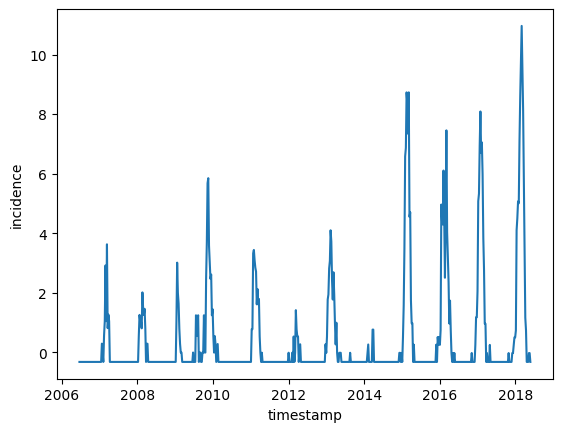

In [28]:

df = train_norm.copy()

node_df = df[df['node'] == 391]


sns.lineplot(node_df, x = 'timestamp', y ='incidence')

In [ ]:

# train_denorm     = reverse_zscore_scaling(train_normalized, params = self.dataloader.norm_params['params'])
# train_denorm     = reverse_log(train_denorm, self.dataloader.logged_params)


# val_denorm       = reverse_zscore_scaling(val_normalized, params = self.dataloader.norm_params['params'])
# val_denorm       = reverse_log(val_denorm, self.dataloader.logged_params)


# test_denorm      = reverse_zscore_scaling(test_normalized, params = self.dataloader.norm_params['params'])
# test_denorm      = reverse_log(test_denorm, self.dataloader.logged_params)


# preds_denorm      = reverse_zscore_scaling(preds_normalized, params = self.dataloader.norm_params['params'])
# preds_denorm      = reverse_log(preds_denorm, self.dataloader.logged_params)

agg_target = preds_normalized.groupby(ml.temporal_column)[ml.target_column].sum().reset_index()
agg_preds  = preds_normalized.groupby(ml.temporal_column)['preds'].sum().reset_index()
ml.aggregated_evaluation_df = pd.merge(agg_target, agg_preds, on=ml.temporal_column)

# agg_target_denorm = preds_denorm.groupby(self.temporal_column)[self.target_column].sum().reset_index()
# agg_preds_denorm  = preds_denorm.groupby(self.temporal_column)['preds'].sum().reset_index()
# self.aggregated_evaluation_df_denorm = pd.merge(agg_target_denorm, agg_preds_denorm, on=self.temporal_column)        

# self.XYt_train_denorm =train_denorm
# self.XYt_val_denorm   =val_denorm
# self.XYt_test_denorm  =test_denorm
# self.preds_denorm     =preds_denorm